In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from pathlib import Path
from io import BytesIO

import requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from ultralytics import YOLO

In [2]:
# Path to trained model
model_path = Path("saved_models/helmet_model.pt")

if not model_path.exists():
    raise FileNotFoundError(
        f"Model not found at: {model_path.resolve()}"
    )

# Load trained model
model = YOLO(str(model_path))

print("Model loaded successfully!")
print("Model path:", model_path.resolve())
print("Classes:", model.names)

Model loaded successfully!
Model path: C:\My Space\Github_Repo\Traffic Violation Detection-Deep Learning\saved_models\helmet_model.pt
Classes: {0: 'helmet', 1: 'no_helmet', 2: 'overloading'}


In [ ]:
image_url = "https://images.hindustantimes.com/img/2022/06/14/550x309/4f0b017a-ec0e-11ec-816d-25a8f4149995_1655230927076.jpg"

In [8]:
def download_image(url):
    """
    Download an image from an internet URL
    and return it as a PIL Image.
    """

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    response = requests.get(
        url,
        headers=headers,
        timeout=15
    )

    response.raise_for_status()

    image = Image.open(
        BytesIO(response.content)
    ).convert("RGB")

    return image

In [9]:
# Download image
image = download_image(image_url)

print("Image downloaded successfully!")
print("Image size:", image.size)


# Run prediction
results = model.predict(
    source=image,
    verbose=False
)

result = results[0]


# Get prediction
top1_class = int(result.probs.top1)
confidence = float(result.probs.top1conf)

predicted_class = model.names[top1_class]


print("\n===================================")
print("       HELMET TEST RESULT")
print("===================================")

print("Predicted Class :", predicted_class)
print("Confidence      :", f"{confidence:.2%}")

Image downloaded successfully!
Image size: (800, 522)

       HELMET TEST RESULT
Predicted Class : no_helmet
Confidence      : 61.97%


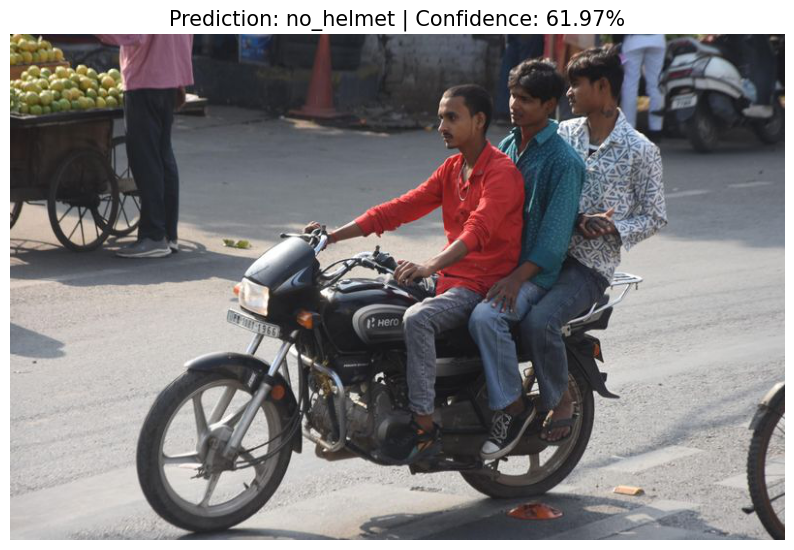

In [10]:
plt.figure(figsize=(10, 7))

plt.imshow(image)
plt.axis("off")

plt.title(
    f"Prediction: {predicted_class} | "
    f"Confidence: {confidence:.2%}",
    fontsize=15
)



plt.show()